In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.graph_objects as go

# ── Chinchilla constants (Hoffmann et al. 2022, Approach 3) ──────────────────
A, alpha = 406.4, 0.3392
B, beta  = 410.7, 0.2849
E        = 1.6934

def chinchilla_loss(N, D):
    return A / N**alpha + B / D**beta + E

# ── Load real training logs ───────────────────────────────────────────────────
BASE = "./results"
# BASE = "experiments/chinchilla/results"
df1  = pd.read_csv(f"{BASE}/model1_8m/loss_log.csv")
df2  = pd.read_csv(f"{BASE}/model2_8m_ctx2n/loss_log.csv")
dfa  = pd.read_csv(f"{BASE}/avg_8m_k2/loss_log.csv")
dfa4 = pd.read_csv(f"{BASE}/avg_8m_k4/loss_log.csv")

# ── Exact parameter counts from model_configs.py ─────────────────────────────
# OLM does NOT tie input/output embeddings, so the vocab embedding appears
# twice.  Formula: N = 2 × vocab × d_model  +  n_layers × 12 × d_model²
# This matches the training log: [model1_8m] Parameters: 14,012,416 (14.0M)
VOCAB = 50_257   # GPT-NeoX BPE

# model1_8m      : d_model=128, n_layers=6, context_len=512,  avg_k=1
# model2_8m_ctx2n: same backbone, context_len=1024 (2× context), avg_k=1
# avg_8m_k2      : same backbone as model1_8m, avg_k=2
# avg_8m_k4      : same backbone as model1_8m, avg_k=4
N1 = N2 = Na = 2 * VOCAB * 128  +  6 * 12 * 128**2    # ≈ 14.0M (all identical)
Na4 = N1                                       # ≈ 14.0M

# ── Theoretical FLOPs/step ───────────────────────────────────────────────────
# Per-layer breakdown over one sequence of L tokens:
#
#   Attention   : Q/K/V proj  6d²·L  +  QKᵀ  2L²d  +  AV  2L²d  +  out proj  2d²·L
#               = L·(8d² + 4Ld)
#   FFN (4× exp): up  8d²·L  +  down  8d²·L  = 16d²·L
#   ──────────────────────────────────────────────────────────────────────────
#   Total / layer                              = L·(24d² + 4Ld)
#
# Full model (training = fwd + bwd ≈ 3× fwd), single sequence:
#   FLOPs/step = 3 × n_layers × L × (24·d² + 4·L·d)
#
# vs old 6·N rule:   6N is context-length blind — same value for model1 and
#   model2 even though model2 processes 2× longer sequences per step.
#   The 4·L²·d attention term correctly scales with L².

def flops_per_step(n_layers, d, context_len, averaging_k=1):
    """
    Training FLOPs for one sequence (single-item batch, fwd + bwd).

    Formula:  3 × n_layers × L × (24·d² + 4·L·d)
    where L = context_len (transformer sequence length).

    For averaging_k > 1 the transformer processes context_len positions,
    but those represent context_len × averaging_k original tokens.
    FLOPs per step are the same as a k=1 model with the same context_len —
    the averaging only affects how many original tokens each step consumes.
    """
    return 3 * n_layers * context_len * (24 * d**2 + 4 * context_len * d)

# Configs from model_configs.py
S1 = flops_per_step(6, 128, 512)    # model1_8m        (k=1, L=512)
S2 = flops_per_step(6, 128, 1024)   # model2_8m_ctx2n  (k=1, L=1024)
Sa = flops_per_step(6, 128, 512)    # avg_8m_k2        (k=2, L=512 — same transformer work)
Sa4 = flops_per_step(6, 128, 512)   # avg_8m_k4        (k=4, L=context_len=512 — same transformer work as model1)

# Original tokens consumed per step
tokens_per_step1 = 512  * 1          # k=1: L × k
tokens_per_step2 = 1024 * 1
tokens_per_stepA = 512  * 2          # k=2: L × k  (each step averages 2 tokens → sees 1024 original tokens)
tokens_per_stepA4 = 512 * 4          # k=4: L × k  (context_len=512 positions × 4 tokens each → 2048 original tokens per sequence)

# ── Chinchilla-optimal budgets ────────────────────────────────────────────────
# D_opt = 20·N original tokens  (Chinchilla — token budget, not step count)
# For avg k=2: transformer needs 20·N positions → 40·N original tokens
D_opt1 = 20 * N1
D_opt2 = 20 * N2
D_optA = 40 * Na
D_optA4 = 80 * Na4

# C_opt = FLOPs/step × number_of_steps
#       = FLOPs/step × (D_opt_tokens / tokens_per_step)
C_opt1 = S1 * (D_opt1 / tokens_per_step1)
C_opt2 = S2 * (D_opt2 / tokens_per_step2)
C_optA = Sa * (D_optA / tokens_per_stepA)
C_optA4 = Sa4 * (D_optA4 / tokens_per_stepA4)
# Note: C_optA  = S1  × (40N/1024) = S1  × (20N/512) = C_opt1  (avg_k2 = model1 at equal compute)
#       C_optA4 = Sa4 × (80N/2048) = Sa4 × (20N/512) = C_opt1  (avg_k4 = model1 at equal compute — same L=512, same FLOPs/step)

MODELS = [
    (df1, "~8M std (ctx=512)",    "#58a6ff", N1, D_opt1, C_opt1),
    (df2, "~8M std (ctx=1024)",   "#f78166", N2, D_opt2, C_opt2),
    (dfa, "~8M + 2× averaging",   "#3fb950", Na, D_optA, C_optA),
    (dfa4, "~8M + 4× averaging",   "#e3b341", Na4, D_optA4, C_optA4),
]

# ── Shared style constants ────────────────────────────────────────────────────
BG, GRID, TEXT, MUTED = "#0d1117", "#21262d", "#e6edf3", "#8b949e"

# ── Matplotlib helpers ────────────────────────────────────────────────────────
def _mpl_style(ax, xlabel, xfmt):
    ax.set_facecolor(BG)
    ax.set_xlabel(xlabel, color=TEXT, fontsize=11)
    ax.set_ylabel("Eval Loss", color=TEXT, fontsize=11)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(xfmt))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.tick_params(colors=MUTED, labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    ax.grid(True, which="major", color=GRID, linewidth=0.7)
    ax.grid(True, which="minor", color=GRID, linewidth=0.3, linestyle=":")
    ax.legend(fontsize=10, framealpha=0.15, edgecolor=GRID,
              labelcolor=TEXT, loc="upper right")

def _mpl_fmt_tok(x, _):
    if x >= 1e9: return f"{x/1e9:.1f}B"
    if x >= 1e6: return f"{x/1e6:.0f}M"
    return str(int(x))

def _mpl_fmt_flops(x, _):
    if x >= 1e18: return f"{x/1e18:.1f}ZF"
    if x >= 1e15: return f"{x/1e15:.1f}PF"
    if x >= 1e12: return f"{x/1e12:.1f}TF"
    return f"{x:.1e}"

# ── Plotly helpers ────────────────────────────────────────────────────────────
def _plotly_layout(title, xaxis_title, yaxis_title):
    return dict(
        title=dict(text=title, font=dict(color=TEXT, size=14)),
        paper_bgcolor=BG, plot_bgcolor=BG,
        xaxis=dict(title=xaxis_title, color=TEXT, gridcolor=GRID,
                   showline=True, linecolor=GRID, tickfont=dict(color=MUTED)),
        yaxis=dict(title=yaxis_title, color=TEXT, gridcolor=GRID,
                   showline=True, linecolor=GRID, tickfont=dict(color=MUTED)),
        legend=dict(bgcolor="rgba(255,255,255,0.05)", bordercolor=GRID,
                    font=dict(color=TEXT)),
        hovermode="x unified",
        width=900, height=550,
    )

def fmt_si(x):
    if x >= 1e18: return f"{x/1e18:.2f} ZF"
    if x >= 1e15: return f"{x/1e15:.2f} PF"
    if x >= 1e12: return f"{x/1e12:.1f} TF"
    if x >= 1e9:  return f"{x/1e9:.2f} GF"
    return f"{x:.2e}"

def fmt_tok(x):
    if x >= 1e9: return f"{x/1e9:.2f}B"
    if x >= 1e6: return f"{x/1e6:.0f}M"
    return str(int(x))

print(f"{'Model':<26} {'ctx':>6} {'k':>3} {'tok/step':>10} {'FLOPs/step':>13} {'D_opt':>10} {'C_opt':>12}")
print("-" * 85)
for label, L, k, S, tps, D_opt, C_opt in [
    ("model1_8m (ctx=512)",   512,  1, S1, tokens_per_step1, D_opt1, C_opt1),
    ("model2_8m (ctx=1024)",  1024, 1, S2, tokens_per_step2, D_opt2, C_opt2),
    ("avg_8m_k2 (ctx=512,k2)",512,  2, Sa,  tokens_per_stepA,  D_optA,  C_optA),
    ("avg_8m_k4 (ctx=512,k4)",512,  4, Sa4, tokens_per_stepA4, D_optA4, C_optA4),
]:
    print(f"{label:<26} {L:>6} {k:>3} {tps:>10,} {S:>13.3e} {fmt_tok(D_opt):>10} {fmt_si(C_opt):>12}")

print()
print(f"FLOPs/step ratio  model2 / model1 = {S2/S1:.4f}×  "
      f"(attention term scales as L²: (1024/512)² contribution → ratio > 2)")
print(f"C_opt ratio       model2 / model1 = {C_opt2/C_opt1:.4f}×")
print(f"C_opt             avg_k2 / model1 = {C_optA/C_opt1:.4f}×  (avg_k2 = model1 at equal compute)")
print(f"C_opt             avg_k4 / model1 = {C_optA4/C_opt1:.4f}×  (avg_k4 = model1 at equal compute — same L=512, same FLOPs/step)")


Model                         ctx   k   tok/step    FLOPs/step      D_opt        C_opt
-------------------------------------------------------------------------------------
model1_8m (ctx=512)           512   1        512     6.040e+09       281M      3.31 PF
model2_8m (ctx=1024)         1024   1      1,024     1.691e+10       281M      4.64 PF
avg_8m_k2 (ctx=512,k2)        512   2      1,024     6.040e+09       562M      3.31 PF
avg_8m_k4 (ctx=512,k4)        512   4      2,048     6.040e+09      1.12B      3.31 PF

FLOPs/step ratio  model2 / model1 = 2.8000×  (attention term scales as L²: (1024/512)² contribution → ratio > 2)
C_opt ratio       model2 / model1 = 1.4000×
C_opt             avg_k2 / model1 = 1.0000×  (avg_k2 = model1 at equal compute)
C_opt             avg_k4 / model1 = 1.0000×  (avg_k4 = model1 at equal compute — same L=512, same FLOPs/step)


Saved: loss_vs_tokens.png


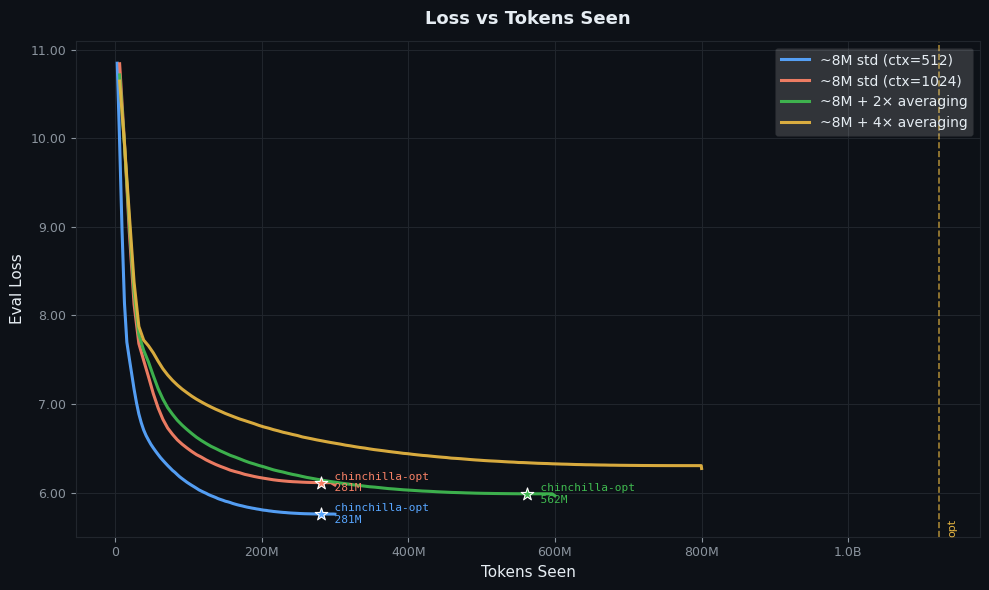

In [7]:
def plot_loss_vs_tokens(models=MODELS, save=True):
    """Static matplotlib: eval loss vs tokens seen with Chinchilla-opt markers."""
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(BG)

    for df, label, color, N, D_opt, _ in models:
        ax.plot(df["tokens_seen"], df["eval_loss"],
                color=color, linewidth=2.2, label=label, alpha=0.95)

        x_max = df["tokens_seen"].max()
        if D_opt <= x_max:
            y_opt = float(np.interp(D_opt, df["tokens_seen"], df["eval_loss"]))
            ax.scatter([D_opt], [y_opt], color=color, s=90, marker="*",
                       edgecolors="white", linewidths=0.8, zorder=5)
            ax.annotate(f"  chinchilla-opt\n  {fmt_tok(D_opt)}",
                        xy=(D_opt, y_opt), color=color,
                        fontsize=8, fontfamily="monospace", va="center")
        else:
            ax.axvline(D_opt, color=color, linewidth=1.2, linestyle="--", alpha=0.7)
            ax.text(D_opt * 1.01, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 4.5,
                    f"opt", color=color, fontsize=8, rotation=90, va="bottom")

    ax.set_title("Loss vs Tokens Seen", color=TEXT,
                 fontsize=13, fontweight="bold", pad=12)
    _mpl_style(ax, "Tokens Seen", _mpl_fmt_tok)

    plt.tight_layout()
    if save:
        fig.savefig("loss_vs_tokens.png", dpi=150, bbox_inches="tight", facecolor=BG)
        print("Saved: loss_vs_tokens.png")
    plt.show()

plot_loss_vs_tokens()

In [8]:
def plot_loss_vs_tokens_interactive(models=MODELS):
    """Interactive plotly: eval loss vs tokens seen with Chinchilla-opt markers."""
    fig = go.Figure()

    for df, label, color, N, D_opt, _ in models:
        fig.add_trace(go.Scatter(
            x=df["tokens_seen"], y=df["eval_loss"],
            mode="lines", name=label,
            line=dict(color=color, width=2.5),
            hovertemplate=f"<b>{label}</b><br>Tokens: %{{x:.3s}}<br>Loss: %{{y:.4f}}<extra></extra>",
        ))

        x_max = df["tokens_seen"].max()
        if D_opt <= x_max:
            y_opt = float(np.interp(D_opt, df["tokens_seen"], df["eval_loss"]))
            fig.add_trace(go.Scatter(
                x=[D_opt], y=[y_opt],
                mode="markers", name=f"chinchilla-opt ({label})",
                marker=dict(color=color, size=14, symbol="star",
                            line=dict(color="white", width=1.5)),
                hovertemplate=(
                    f"<b>Chinchilla-opt</b><br>"
                    f"N = {N/1e6:.1f}M<br>"
                    f"D_opt = {fmt_tok(D_opt)}<br>"
                    f"Loss ≈ %{{y:.4f}}<extra></extra>"
                ),
            ))
        else:
            fig.add_vline(x=D_opt,
                          line=dict(color=color, width=1.5, dash="dash"),
                          annotation_text=f"opt ({label.split()[0]})",
                          annotation_font=dict(color=color, size=10),
                          annotation_position="top right")

    layout = _plotly_layout("Loss vs Tokens Seen — Interactive", "Tokens Seen", "Eval Loss")
    layout["xaxis"]["tickformat"] = ".2s"
    fig.update_layout(**layout)
    fig.show()

plot_loss_vs_tokens_interactive()

Saved: loss_vs_compute.png


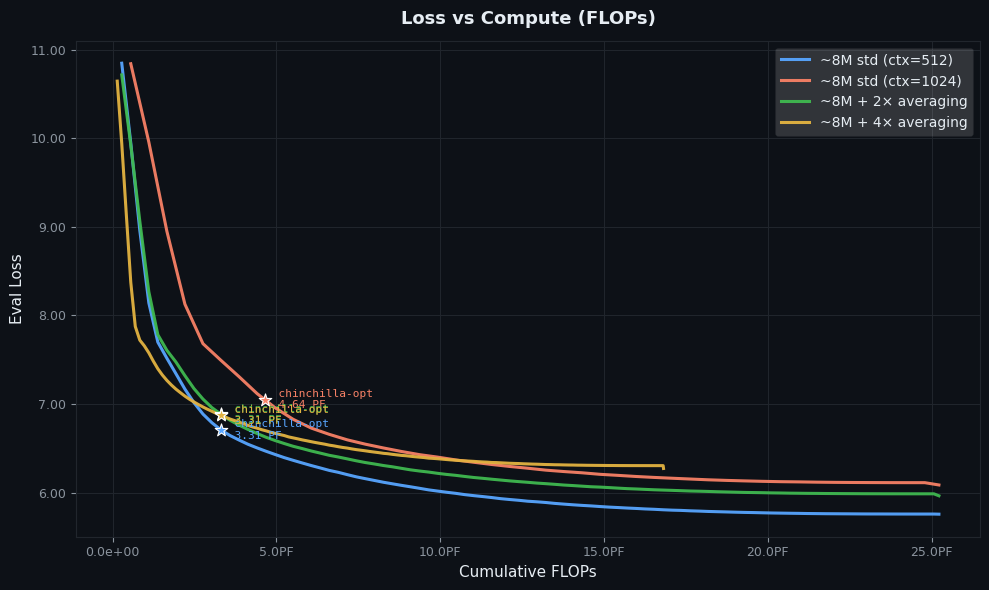

In [9]:
def plot_loss_vs_compute(models=MODELS, save=True):
    """Static matplotlib: eval loss vs cumulative FLOPs with Chinchilla-opt markers."""
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(BG)

    for df, label, color, N, _, C_opt in models:
        ax.plot(df["cumulative_flops"], df["eval_loss"],
                color=color, linewidth=2.2, label=label, alpha=0.95)

        c_max = df["cumulative_flops"].max()
        if C_opt <= c_max:
            y_opt = float(np.interp(C_opt, df["cumulative_flops"], df["eval_loss"]))
            ax.scatter([C_opt], [y_opt], color=color, s=90, marker="*",
                       edgecolors="white", linewidths=0.8, zorder=5)
            ax.annotate(f"  chinchilla-opt\n  {fmt_si(C_opt)}",
                        xy=(C_opt, y_opt), color=color,
                        fontsize=8, fontfamily="monospace", va="center")
        else:
            ax.axvline(C_opt, color=color, linewidth=1.2, linestyle="--", alpha=0.7)

    ax.set_title("Loss vs Compute (FLOPs)", color=TEXT,
                 fontsize=13, fontweight="bold", pad=12)
    _mpl_style(ax, "Cumulative FLOPs", _mpl_fmt_flops)

    plt.tight_layout()
    if save:
        fig.savefig("loss_vs_compute.png", dpi=150, bbox_inches="tight", facecolor=BG)
        print("Saved: loss_vs_compute.png")
    plt.show()

plot_loss_vs_compute()

In [10]:
def plot_loss_vs_compute_interactive(models=MODELS):
    """Interactive plotly: eval loss vs cumulative FLOPs with Chinchilla-opt markers."""
    fig = go.Figure()

    for df, label, color, N, _, C_opt in models:
        fig.add_trace(go.Scatter(
            x=df["cumulative_flops"], y=df["eval_loss"],
            mode="lines", name=label,
            line=dict(color=color, width=2.5),
            hovertemplate=f"<b>{label}</b><br>FLOPs: %{{x:.3e}}<br>Loss: %{{y:.4f}}<extra></extra>",
        ))

        c_max = df["cumulative_flops"].max()
        if C_opt <= c_max:
            y_opt = float(np.interp(C_opt, df["cumulative_flops"], df["eval_loss"]))
            fig.add_trace(go.Scatter(
                x=[C_opt], y=[y_opt],
                mode="markers", name=f"chinchilla-opt ({label})",
                marker=dict(color=color, size=14, symbol="star",
                            line=dict(color="white", width=1.5)),
                hovertemplate=(
                    f"<b>Chinchilla-opt</b><br>"
                    f"N = {N/1e6:.1f}M<br>"
                    f"C_opt = {fmt_si(C_opt)}<br>"
                    f"Loss ≈ %{{y:.4f}}<extra></extra>"
                ),
            ))
        else:
            fig.add_vline(x=C_opt,
                          line=dict(color=color, width=1.5, dash="dash"),
                          annotation_text=f"opt ({label.split()[0]})",
                          annotation_font=dict(color=color, size=10),
                          annotation_position="top right")

    layout = _plotly_layout("Loss vs Compute (FLOPs) — Interactive", "Cumulative FLOPs", "Eval Loss")
    fig.update_layout(**layout)
    fig.show()

plot_loss_vs_compute_interactive()